# Семинар 2: Языковое моделирование и введение в генерацию текста

**Модуль 1** | Неделя 1 | Задачи генерации в NLP

---

## Цели семинара

После выполнения этого семинара вы научитесь:

1. Различать типы Transformer-моделей на практике: **encoder-only**, **decoder-only**, **encoder-decoder**
2. Загружать и использовать предобученные модели через **HuggingFace**
3. Вычислять **perplexity** модели на тексте
4. Генерировать текст с разными стратегиями: **greedy**, **sampling**, **top-k**, **top-p**, **beam search**
5. Понимать концепцию **RAG** (Retrieval-Augmented Generation) и построить минимальный прототип

**Связь с конспектами:** 1.1 (виды предобученных LM), 1.5 (языковое моделирование)

## Блок 0: Настройка окружения

In [3]:
# Установка зависимостей (для Google Colab)
# При локальном запуске можно пропустить, если пакеты уже установлены
!pip install -q transformers datasets evaluate accelerate sentencepiece
!pip install -q sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.3 MB/s eta 0:00:00


In [4]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    device = torch.device("cpu")
    print("WARNING: GPU не доступен, используется CPU")
    print("Семинар будет работать на CPU, но медленнее")

GPU: Tesla T4
VRAM: 14.6 GB


In [5]:
import numpy as np
from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM, AutoModelForSeq2SeqLM, AutoModelForMaskedLM
from transformers import pipeline

---

## Блок 1: Типы Transformer-моделей на практике (20 мин)

### Теория

В конспекте 1.1 мы разобрали три основных типа архитектур на базе Transformer. Вспомним ключевые отличия:

| Характеристика | Encoder-only (BERT) | Decoder-only (GPT) | Encoder-Decoder (T5) |
|---|---|---|---|
| **Внимание** | Bidirectional (видит весь контекст) | Causal (видит только левый контекст) | Encoder: bidirectional, Decoder: causal + cross-attention |
| **Задача обучения** | Masked Language Model (MLM) | Next Token Prediction | Span corruption / text-to-text |
| **Применение** | Классификация, NER, similarity | Генерация текста, чат-боты | Перевод, суммаризация, Q&A |
| **Примеры** | BERT, RoBERTa, DeBERTa | GPT, LLaMA, Qwen, Mistral | T5, mT5, BART |

### Позиционные кодирования: от синусоидальных к RoPE

Оригинальный Transformer использовал **синусоидальные позиционные кодирования** (sinusoidal PE) — фиксированные функции $\sin$ и $\cos$ разных частот:

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d}}\right), \quad PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d}}\right)$$



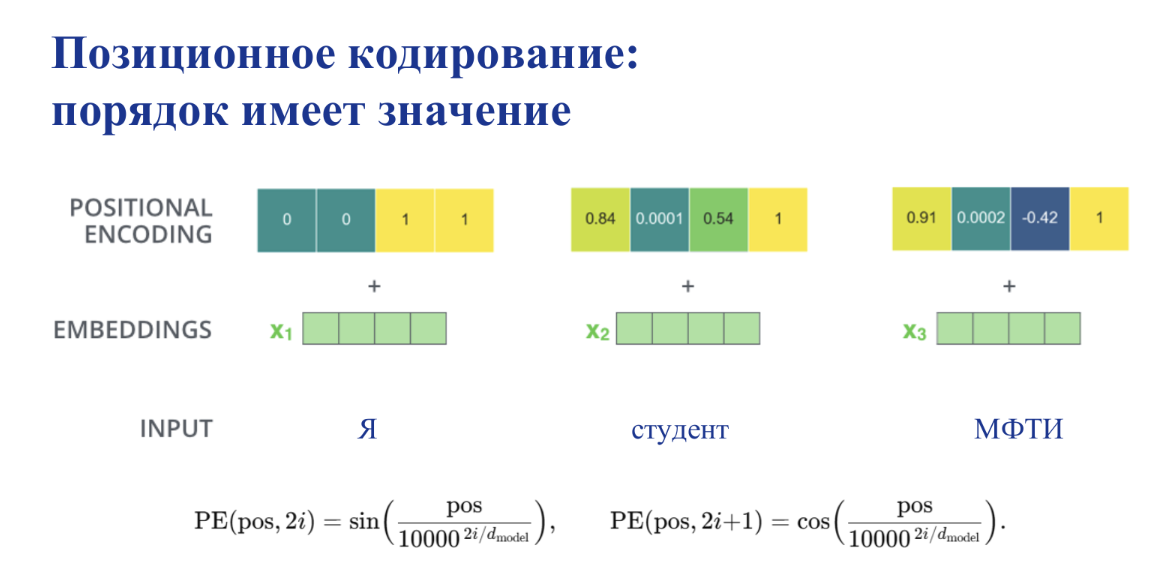

**RoPE (Rotary Position Embedding)** — современная альтернатива, используемая в LLaMA, Qwen, Mistral:

- Вместо добавления позиции к эмбеддингу, RoPE **вращает** вектор query/key в пространстве
- Скалярное произведение двух повёрнутых векторов зависит только от **относительной** позиции между ними
- Это позволяет модели лучше обобщаться на **длинные контексты** (через NTK-scaling и другие техники)

На практике: если модель использует RoPE (как Qwen 3), она может работать с контекстом в 32K–128K токенов, тогда как модели с sinusoidal PE обычно ограничены 512–2048 токенами.

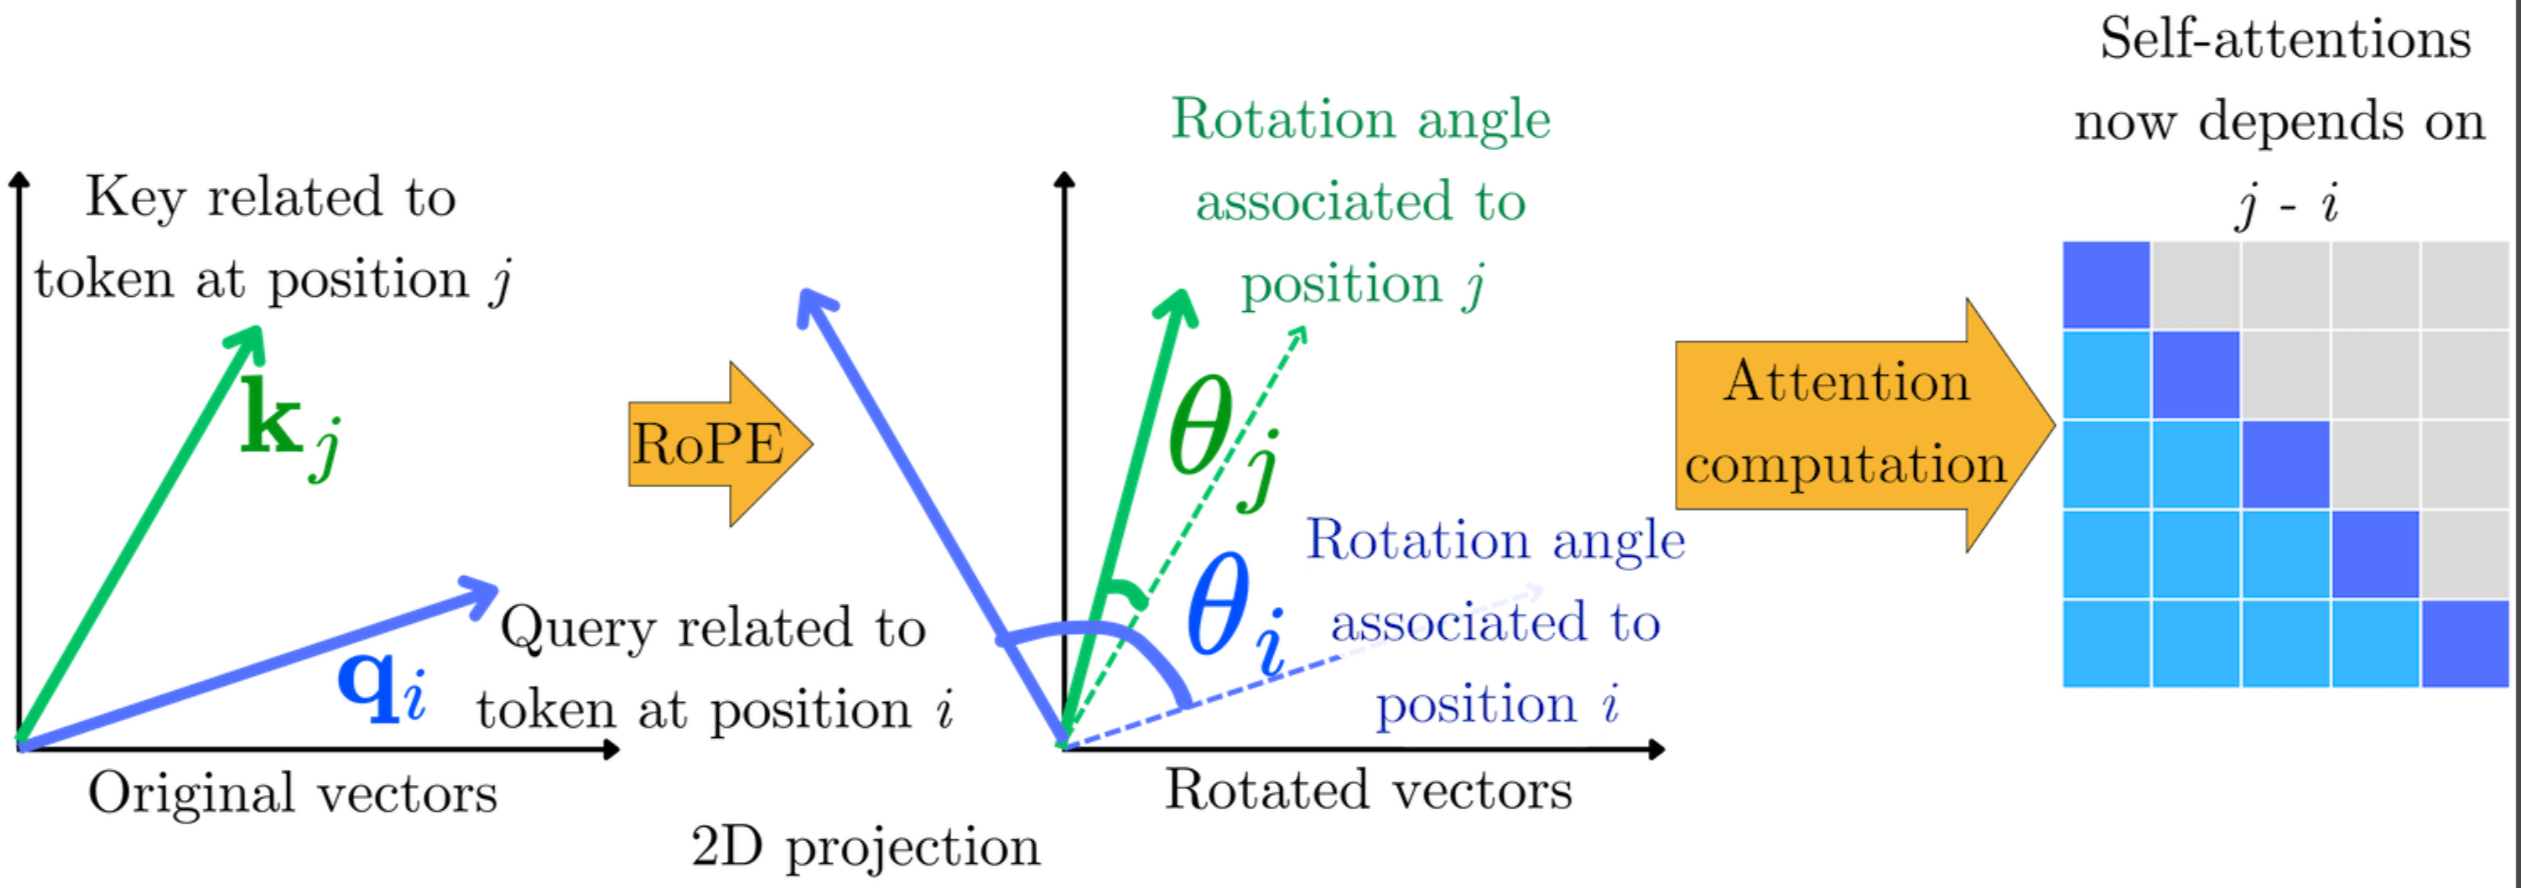

### Практика: загрузка и сравнение трёх типов моделей

Загрузим по одной модели каждого типа и посмотрим на их архитектуру и возможности.

In [11]:
# Encoder-only: компактная русскоязычная модель
encoder_name = "cointegrated/rubert-tiny2"
encoder_tokenizer = AutoTokenizer.from_pretrained(encoder_name)
encoder_model = AutoModelForMaskedLM.from_pretrained(encoder_name).to(device)

print(f"=== Encoder-only: {encoder_name} ===")
print(f"Параметров: {sum(p.numel() for p in encoder_model.parameters()) / 1e6:.1f}M")
print(f"Размер словаря: {encoder_tokenizer.vocab_size:,}")
print(f"Макс. длина: {encoder_tokenizer.model_max_length}")
print(f"Hidden size: {encoder_model.config.hidden_size}")
print(f"Число слоёв: {encoder_model.config.num_hidden_layers}")

Loading weights:   0%|          | 0/58 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: cointegrated/rubert-tiny2
Key                          | Status     |  | 
-----------------------------+------------+--+-
cls.seq_relationship.weight  | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
bert.pooler.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias    | UNEXPECTED |  | 
bert.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


=== Encoder-only: cointegrated/rubert-tiny2 ===
Параметров: 29.3M
Размер словаря: 83,828
Макс. длина: 2048
Hidden size: 312
Число слоёв: 3


In [6]:
# Decoder-only: русскоязычная GPT-модель
decoder_name = "ai-forever/rugpt3small_based_on_gpt2"
decoder_tokenizer = AutoTokenizer.from_pretrained(decoder_name)
decoder_model = AutoModelForCausalLM.from_pretrained(decoder_name).to(device)

print(f"=== Decoder-only: {decoder_name} ===")
print(f"Параметров: {sum(p.numel() for p in decoder_model.parameters()) / 1e6:.1f}M")
print(f"Размер словаря: {decoder_tokenizer.vocab_size:,}")
print(f"Макс. длина: {decoder_model.config.n_positions}")
print(f"Hidden size: {decoder_model.config.n_embd}")
print(f"Число слоёв: {decoder_model.config.n_layer}")
print(f"Позиционное кодирование: Learned (абсолютное)")

config.json:   0%|          | 0.00/720 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/574 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/551M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: ai-forever/rugpt3small_based_on_gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 
transformer.h.{0...11}.attn.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


=== Decoder-only: ai-forever/rugpt3small_based_on_gpt2 ===
Параметров: 163.8M
Размер словаря: 50,257
Макс. длина: 2048
Hidden size: 768
Число слоёв: 12
Позиционное кодирование: Learned (абсолютное)


In [26]:
# Encoder-Decoder: multilingual T5
encdec_name = "google/mt5-small"
encdec_tokenizer = AutoTokenizer.from_pretrained(encdec_name)
encdec_model = AutoModelForSeq2SeqLM.from_pretrained(encdec_name).to(device)

print(f"=== Encoder-Decoder: {encdec_name} ===")
print(f"Параметров: {sum(p.numel() for p in encdec_model.parameters()) / 1e6:.1f}M")
print(f"Размер словаря: {encdec_tokenizer.vocab_size:,}")
print(f"Hidden size: {encdec_model.config.d_model}")
print(f"Encoder слоёв: {encdec_model.config.num_layers}")
print(f"Decoder слоёв: {encdec_model.config.num_decoder_layers}")
print(f"Позиционное кодирование: Relative (T5-style)")

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


=== Encoder-Decoder: google/mt5-small ===
Параметров: 556.3M
Размер словаря: 250,100
Hidden size: 512
Encoder слоёв: 8
Decoder слоёв: 8
Позиционное кодирование: Relative (T5-style)


### Сравнительная таблица

In [8]:
models_info = {
    "rubert-tiny2 (Encoder)": encoder_model,
    "rugpt3small (Decoder)": decoder_model,
    "mt5-small (Enc-Dec)": encdec_model,
}

print(f"{'Модель':<30} {'Параметры':<15} {'VRAM (MB)':<12}")
print("-" * 57)
for name, model in models_info.items():
    n_params = sum(p.numel() for p in model.parameters())
    # Приблизительный расчёт VRAM: float32 = 4 байта на параметр
    vram_mb = n_params * 4 / 1024**2
    print(f"{name:<30} {n_params/1e6:<15.1f} {vram_mb:<12.0f}")

Модель                         Параметры       VRAM (MB)   
---------------------------------------------------------
rubert-tiny2 (Encoder)         29.2            111         
rugpt3small (Decoder)          163.8           625         
mt5-small (Enc-Dec)            556.3           2122        


### Демонстрация: что умеет каждый тип модели

Каждый тип модели решает свою задачу. Используем `pipeline` API для наглядности.

In [12]:
# Encoder-only: задача fill-mask (MLM)
# Модель предсказывает замаскированное слово, используя ВЕСЬ контекст (и слева, и справа)
# Передаём загруженные объекты model/tokenizer, чтобы не создавать дубликат в VRAM
fill_mask = pipeline("fill-mask", model=encoder_model, tokenizer=encoder_tokenizer, device=device)

text = "Москва — [MASK] России."
print(f"Задача: Fill-Mask")
print(f"Вход: '{text}'\n")

results = fill_mask(text, top_k=5)
for r in results:
    print(f"  {r['token_str']:<15} (score: {r['score']:.3f})")

Задача: Fill-Mask
Вход: 'Москва — [MASK] России.'

  в               (score: 0.177)
  столица         (score: 0.133)
  Новости         (score: 0.055)
  из              (score: 0.021)
  Почта           (score: 0.021)


In [13]:
# Decoder-only: задача text-generation
# Модель продолжает текст, генерируя по одному токену за раз (авторегрессивно)
text_gen = pipeline(
    "text-generation",
    model=decoder_model,
    tokenizer=decoder_tokenizer,
    device=device,
    # pad_token_id нужен, т.к. у GPT-2 нет специального pad-токена
    pad_token_id=decoder_tokenizer.eos_token_id
)

prompt = "Искусственный интеллект в будущем"
print(f"Задача: Text Generation")
print(f"Вход: '{prompt}'\n")

result = text_gen(prompt, max_new_tokens=50, do_sample=True, temperature=0.7)
print(f"Выход: {result[0]['generated_text']}")

Passing `generation_config` together with generation-related arguments=({'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Passing `generation_config` together with generation-related arguments=({'temperature', 'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=50) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Задача: Text Generation
Вход: 'Искусственный интеллект в будущем'

Выход: Искусственный интеллект в будущем
Наталья Евгеньевна Кудрявцева




Наталья Кудрявцева

Искусственный интеллект в будущем





















In [27]:
# Encoder-Decoder: задача text2text-generation
# mt5-small — это базовая модель без дообучения на конкретную задачу,
# поэтому результаты будут не идеальны. В реальных задачах (перевод, суммаризация)
# используют дообученные варианты
# Раньше в transformers можно было выбрать text2text-generation, но его перевели в ветку для отказа
# Поэтому мы будем использовать прямой вызов
def seq2seq_generate(model, tokenizer, prompt, max_new_tokens=50, num_beams=4, do_sample=False, temperature=1.0):
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(model.device)
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=num_beams,
            do_sample=do_sample,
            temperature=temperature,
        )
    return tokenizer.decode(output_ids[0], skip_special_tokens=True)

prompt = "translate English to German: The house is wonderful."
print("Задача: Text-to-Text (Seq2Seq через generate())")
print(f"Вход: '{prompt}'\n")

out = seq2seq_generate(encdec_model, encdec_tokenizer, prompt, max_new_tokens=50)
print("Выход:", out)

print("\nПримечание: mt5-small — базовая модель без дообучения на перевод, качество может быть низким.")
print("Для перевода лучше использовать дообученную модель (например, Helsinki-NLP/opus-mt-en-de).")

Задача: Text-to-Text (Seq2Seq через generate())
Вход: 'translate English to German: The house is wonderful.'

Выход: <extra_id_0>

Примечание: mt5-small — базовая модель без дообучения на перевод, качество может быть низким.
Для перевода лучше использовать дообученную модель (например, Helsinki-NLP/opus-mt-en-de).


In [28]:
seq2seq_generate(encdec_model, encdec_tokenizer, "The <extra_id_0> is wonderful.", max_new_tokens=50)

'<extra_id_0> atmosphere <extra_id_1>.'

### Ключевые различия на практике

1. **Encoder-only** (BERT) видит весь контекст → отлично для задач **понимания** текста (классификация, NER, STS). Не может генерировать текст.

2. **Decoder-only** (GPT) видит только предыдущие токены → хорош для **генерации**. Современные LLM (GPT-5, LLaMA, Qwen) — это decoder-only модели.

3. **Encoder-Decoder** (T5) — encoder понимает входной текст, decoder генерирует выход → идеален для задач **трансформации** текста (перевод, суммаризация).

Тренд 2023-2025: decoder-only модели доминируют. Даже задачи, традиционно решавшиеся encoder-decoder (перевод, суммаризация), теперь часто решают через промптинг decoder-only моделей.

In [ ]:
# Освобождаем память от моделей, которые больше не понадобятся
del encoder_model, encdec_model, fill_mask, text_gen, out
del encoder_tokenizer, encdec_tokenizer
torch.cuda.empty_cache() if torch.cuda.is_available() else None
print("Память очищена. Оставили только rugpt3small для следующих блоков.")

---

## Блок 2: Языковое моделирование — Perplexity (20 мин)

### Теория

**Языковое моделирование** — это задача предсказания следующего токена по контексту:

$$P(w_t \mid w_1, w_2, \ldots, w_{t-1})$$

Качество модели измеряется через **cross-entropy loss** — среднюю отрицательную логарифмическую вероятность правильных токенов:

$$H = -\frac{1}{N} \sum_{t=1}^{N} \log P(w_t \mid w_1, \ldots, w_{t-1})$$

**Perplexity (PPL)** — экспонента cross-entropy, интерпретируется как «среднее число вариантов, между которыми модель выбирает»:

$$\text{PPL} = \exp(H) = \exp\left(-\frac{1}{N} \sum_{t=1}^{N} \log P(w_t \mid w_1, \ldots, w_{t-1})\right)$$

**Интерпретация:**
- PPL = 1 → модель идеально предсказывает каждый следующий токен
- PPL = 10 → модель в среднем «колеблется» между 10 вариантами
- PPL = V (размер словаря) → модель выбирает случайно

**Важно:** PPL можно сравнивать только между моделями с **одинаковым токенизатором** (или на уровне символов). Разные токенизации дают разное N, и PPL не будет сопоставим напрямую.

### Бенчмарки для оценки языковых моделей

Perplexity — внутренняя метрика модели (насколько хорошо она предсказывает текст). Для оценки практической полезности используют **стандартные бенчмарки** (подробнее — в конспекте 1.5):

| Тип модели | Бенчмарки | Что измеряют |
|------------|-----------|-------------|
| **Encoder** | GLUE, SuperGLUE | Понимание текста: NLI, STS, QA |
| **Decoder (LLM)** | MMLU / ruMMLU | Экспертные знания (57 тем) |
| | MERA (21 задача) | Русскоязычные задачи (аналог SuperGLUE + reasoning) |
| | HumanEval | Генерация кода |
| | GSM8k | Математика |

Мы вернёмся к бенчмаркам подробнее в **семинаре 6**.

### Практика: вычисляем perplexity

Реализуем функцию `compute_perplexity` и посмотрим, как PPL ведёт себя на разных типах текста.

In [31]:
import torch.nn.functional as F


def compute_perplexity(model, tokenizer, text, max_length=512):
    """
    Вычисляет perplexity авторегрессивной модели на тексте.

    Для каждого токена t модель предсказывает P(w_t | w_1, ..., w_{t-1}).
    PPL = exp(средняя cross-entropy по всем токенам).
    """
    # Токенизируем текст
    encodings = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_length
    )
    input_ids = encodings.input_ids.to(model.device)

    n_tokens = input_ids.size(1)
    if n_tokens < 2:
        return float('inf')  # нужен хотя бы один переход

    with torch.no_grad():
        outputs = model(input_ids)
        # logits: [batch, seq_len, vocab_size]
        logits = outputs.logits

    # Сдвиг: logits[t] предсказывает токен input_ids[t+1]
    # .float() — приводим к float32, чтобы избежать overflow в softmax при float16
    # (словарь Qwen3 ~150K токенов — softmax по такому числу в float16 может дать inf/nan)
    shift_logits = logits[:, :-1, :].contiguous().float()
    shift_labels = input_ids[:, 1:].contiguous()

    # Cross-entropy для каждого токена
    loss = F.cross_entropy(
        shift_logits.view(-1, shift_logits.size(-1)),
        shift_labels.view(-1),
        reduction='mean'
    )

    ppl = torch.exp(loss).item()
    return ppl


print("Функция compute_perplexity готова")

Функция compute_perplexity готова


In [32]:
# Тестируем на разных типах текста
texts = {
    "Связный текст (новость)": (
        "Президент России провёл совещание по вопросам развития "
        "информационных технологий в стране. На встрече обсуждались "
        "перспективы внедрения искусственного интеллекта в государственное управление."
    ),
    "Простое предложение": (
        "Кошка сидит на окне и смотрит на улицу."
    ),
    "Случайный набор слов": (
        "Стол бежать фиолетовый вчера кислород программирование "
        "мечта трактор синхронизация парадокс яблоко квантовый."
    ),
    "Текст на другом языке (англ.)": (
        "The quick brown fox jumps over the lazy dog. "
        "This is a common English sentence used for testing."
    ),
    "Повторяющийся текст": (
        "Привет мир. Привет мир. Привет мир. Привет мир. Привет мир."
    ),
}

print(f"Модель: {decoder_name}\n")
print(f"{'Тип текста':<35} {'PPL':>10} {'Токенов':>10}")
print("-" * 57)

for label, text in texts.items():
    ppl = compute_perplexity(decoder_model, decoder_tokenizer, text)
    n_tokens = len(decoder_tokenizer.encode(text))
    print(f"{label:<35} {ppl:>10.1f} {n_tokens:>10}")

Модель: ai-forever/rugpt3small_based_on_gpt2

Тип текста                                 PPL    Токенов
---------------------------------------------------------
Связный текст (новость)                   16.8         24
Простое предложение                       10.7         10
Случайный набор слов                    5002.9         19
Текст на другом языке (англ.)             48.3         29
Повторяющийся текст                       16.9         15


### Что мы наблюдаем

- **Связный русский текст** → низкая PPL: модель обучена на таких текстах
- **Случайные слова** → высокая PPL: нет логической связи, сложно предсказать
- **Английский текст** → высокая PPL: модель обучена на русском
- **Повторяющийся текст** → низкая PPL: после первого повторения паттерн легко предсказать

### Сравнение perplexity двух моделей

Загрузим современную multilingual модель **Qwen3-0.6B** (май 2025) и сравним с rugpt3small.

> **Напоминание:** PPL rugpt3small и Qwen3 нельзя сравнивать напрямую — у них разные токенизаторы (словарь ~50K vs ~150K). Сравнение ниже — для иллюстрации поведения моделей на разных типах текста, а не для строгого ранжирования.

In [33]:
# Загружаем Qwen3-0.6B-Base — современную multilingual модель (май 2025)
# Используем Base-версию, т.к. для PPL и чистой генерации нужна именно base-модель
# (instruct-версия Qwen3-0.6B обучена на следование инструкциям и даст искажённый PPL)
qwen_name = "Qwen/Qwen3-0.6B-Base"
qwen_tokenizer = AutoTokenizer.from_pretrained(qwen_name)
qwen_model = AutoModelForCausalLM.from_pretrained(qwen_name, torch_dtype=torch.float16).to(device)
# ВНИМАНИЕ, если запускаете на CPU, то torch.float16 может привести к странному поведению и ошибкам. На CPU используйте float32

print(f"Модель: {qwen_name}")
print(f"Параметров: {sum(p.numel() for p in qwen_model.parameters()) / 1e6:.0f}M")
print(f"Размер словаря: {qwen_tokenizer.vocab_size:,}")
print(f"Позиционное кодирование: RoPE (поддержка до 32K токенов)")

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.19G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

Модель: Qwen/Qwen3-0.6B-Base
Параметров: 596M
Размер словаря: 151,643
Позиционное кодирование: RoPE (поддержка до 32K токенов)


In [34]:
# Сравниваем perplexity двух моделей на одних и тех же текстах
test_texts = {
    "Русская новость": (
        "Учёные из Новосибирска разработали новый метод анализа данных "
        "на основе машинного обучения, который позволяет предсказывать "
        "землетрясения с точностью до 80 процентов."
    ),
    "Английский текст": (
        "Machine learning has revolutionized the way we process and analyze data. "
        "Deep neural networks achieve state-of-the-art results on many benchmarks."
    ),
    "Код на Python": (
        "def fibonacci(n):\n    if n <= 1:\n        return n\n    return fibonacci(n-1) + fibonacci(n-2)"
    ),
    "Случайные слова": (
        "Ложка вертолёт фиолетовый бежать созвездие программа "
        "квантовый синхронизация мечтать парадокс яблоко."
    ),
}

print(f"{'Текст':<25} {'rugpt3small':>15} {'Qwen3-0.6B':>15}")
print("-" * 57)

for label, text in test_texts.items():
    ppl_gpt = compute_perplexity(decoder_model, decoder_tokenizer, text)
    ppl_qwen = compute_perplexity(qwen_model, qwen_tokenizer, text)
    print(f"{label:<25} {ppl_gpt:>15.1f} {ppl_qwen:>15.1f}")

Текст                         rugpt3small      Qwen3-0.6B
---------------------------------------------------------
Русская новость                      23.5             4.2
Английский текст                     24.8             7.3
Код на Python                         4.9             1.7
Случайные слова                    2643.4            36.2


### Анализ результатов

**Важно помнить:** PPL зависит от токенизации. У Qwen3 словарь ~150K токенов, а у rugpt3small ~50K. Один и тот же текст будет разбит на разное число токенов, что влияет на PPL.

Что мы ожидаем:
- **Русский текст**: Qwen3 вероятно покажет лучший PPL — это более крупная и современная модель, обученная на большем корпусе
- **Английский текст**: rugpt3small покажет плохой PPL (обучен на русском), Qwen3 — хороший (multilingual)
- **Код**: Qwen3 обучен в т.ч. на коде, rugpt3small — нет
- **Случайные слова**: обе модели покажут высокий PPL

---

## Блок 3: Генерация текста — стратегии декодирования (25 мин)

### Теория

При генерации текста модель на каждом шаге выдаёт распределение вероятностей по словарю: $P(w_t \mid w_1, \ldots, w_{t-1})$. Как выбрать следующий токен?

#### 1. Greedy Decoding
Выбираем токен с максимальной вероятностью:
$$w_t = \arg\max_{w} P(w \mid w_1, \ldots, w_{t-1})$$
- **Плюс**: быстро, детерминированно
- **Минус**: склонен к повторениям, не рассматривает альтернативные пути

#### 2. Beam Search
Поддерживаем $k$ лучших гипотез (beams) параллельно:
- На каждом шаге расширяем каждую гипотезу на все возможные токены
- Оставляем top-$k$ по суммарной log-вероятности
- **Плюс**: находит более вероятные последовательности, чем greedy
- **Минус**: результат часто «скучный» и повторяющийся

#### 3. Sampling с температурой
Семплируем из распределения, масштабированного температурой $T$:
$$P(w_t) = \frac{\exp(z_t / T)}{\sum_j \exp(z_j / T)}$$
- $T < 1$: распределение «острее» → модель увереннее, текст предсказуемее
- $T = 1$: исходное распределение
- $T > 1$: распределение «площе» → больше разнообразия, но больше ошибок

#### 4. Top-k Sampling
Семплируем только из $k$ самых вероятных токенов (остальные обнуляются):
- Отсекает маловероятные токены (шум)
- **Минус**: фиксированное $k$ не учитывает «уверенность» модели

#### 5. Top-p (Nucleus) Sampling
Семплируем из минимального набора токенов, чья суммарная вероятность ≥ $p$:
- Адаптивно: если модель уверена — выбор из 2-3 токенов, если нет — из сотен
- Обычно $p = 0.9$–$0.95$

#### 6. Repetition Penalty
Штрафуем токены, которые уже встречались в сгенерированном тексте:
$$z_t' = z_t / \alpha \quad \text{если } w_t \text{ уже встречался}$$
где $\alpha > 1$ снижает вероятность повторения.

> **Подробнее** стратегии декодирования будут разобраны в **Модуле 2** (семинары 3-4). Здесь — знакомство и практика.

### Практика: генерация с разными стратегиями

Используем rugpt3small для наглядного сравнения. Позже попробуем Qwen3-0.6B.

In [35]:
def generate_text(model, tokenizer, prompt, **kwargs):
    """Генерирует текст и возвращает только новые токены."""
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    input_len = inputs.input_ids.shape[1]

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=kwargs.pop("max_new_tokens", 80),
            pad_token_id=tokenizer.eos_token_id,
            **kwargs
        )

    # Декодируем только сгенерированные токены (без промпта)
    generated = tokenizer.decode(outputs[0][input_len:], skip_special_tokens=True)
    return generated


print("Функция generate_text готова")

Функция generate_text готова


In [36]:
prompt = "Нейронные сети научились"

strategies = {
    "Greedy (do_sample=False)": {
        "do_sample": False
    },
    "Beam search (num_beams=5)": {
        "do_sample": False,
        "num_beams": 5
    },
    "Sampling (T=0.7)": {
        "do_sample": True,
        "temperature": 0.7
    },
    "Top-k (k=50)": {
        "do_sample": True,
        "top_k": 50
    },
    "Top-p (p=0.9)": {
        "do_sample": True,
        "top_p": 0.9
    },
    "Top-p + repetition penalty": {
        "do_sample": True,
        "top_p": 0.9,
        "repetition_penalty": 1.3
    },
}

print(f"Промпт: '{prompt}'\n")
print("=" * 80)

for name, params in strategies.items():
    result = generate_text(decoder_model, decoder_tokenizer, prompt, **params)
    print(f"\n--- {name} ---")
    print(result)
    print()

Промпт: 'Нейронные сети научились'


--- Greedy (do_sample=False) ---
 создавать виртуальные миры, которые могут быть использованы для создания виртуальных миров.  В настоящее время в мире существует около 200 виртуальных миров, которые могут быть использованы для создания виртуальных миров.  В настоящее время в мире существует около 200 виртуальных миров, которые могут быть использованы для создания виртуальных миров.  В настоящее время в мире существует около 200 виртуальных миров, которые могут быть использованы для создания


--- Beam search (num_beams=5) ---
 создавать виртуальные миры.













































































--- Sampling (T=0.7) ---
 обрабатывать новые сигналы, которые могут быть полезны для контроля за состоянием здоровья людей.  Для работы с ними достаточно всего одного элемента.  В результате ученые смогли создать уникальные алгоритмы, которые позволяют менять привычные сигналы в реальном времени.  К примеру, если они настр

### Влияние температуры

Посмотрим, как температура влияет на генерацию.

In [37]:
prompt = "В далёком будущем люди"
temperatures = [0.1, 0.5, 1.0, 1.5]

print(f"Промпт: '{prompt}'\n")

for temp in temperatures:
    result = generate_text(
        decoder_model, decoder_tokenizer, prompt,
        do_sample=True, temperature=temp, top_p=0.95
    )
    print(f"--- T={temp} ---")
    print(result)
    print()

Промпт: 'В далёком будущем люди'

--- T=0.1 ---
 будут жить в мире, где нет войн и насилия.  И это будет мир, в котором люди будут жить в мире, где нет войн и насилия.  И это будет мир, в котором люди будут жить в мире, где нет войн и насилия.  И это будет мир, в котором люди будут жить в мире, где нет войн и насилия.  И это будет мир, в котором люди

--- T=0.5 ---
 будут жить в разных мирах, но в одном мире будет жить человек, который будет управлять миром.





























































--- T=1.0 ---
 будут понимать, что за все время своего существования они были лишены всякой возможности стать полноценными творцами. 



10230760	nvoloxina	2012-05-04 17:50:00	Мягко сказано - не по адресу... Не могу молчать...


10230761	nvoloxina	2012-04-19

--- T=1.5 ---
 начнут создавать собственные копии ДНК и таким путём люди откроют для себя все свойства живых организмов."(Вспоминался как я однажды посмотрел сериал "Спасатели")

Так вот это уже похоже на какой - то 

### Генерация с Qwen3-0.6B

Сравним качество генерации более современной модели.

In [38]:
prompt_ru = "Искусственный интеллект в ближайшие годы"

print(f"Промпт: '{prompt_ru}'\n")

print("--- rugpt3small (125M) ---")
result_gpt = generate_text(
    decoder_model, decoder_tokenizer, prompt_ru,
    do_sample=True, temperature=0.7, top_p=0.9, max_new_tokens=100
)
print(result_gpt)

print("\n--- Qwen3-0.6B-Base (600M) ---")
result_qwen = generate_text(
    qwen_model, qwen_tokenizer, prompt_ru,
    do_sample=True, temperature=0.7, top_p=0.9, max_new_tokens=100
)
print(result_qwen)

Промпт: 'Искусственный интеллект в ближайшие годы'

--- rugpt3small (125M) ---
 
 В последнее время все больше внимания уделяется вопросам искусственного интеллекта, который представляет собой компьютерную технологию, которая способна осуществлять анализ и прогнозирование, а также прогнозирование событий.  Это, в свою очередь, может помочь в формировании прогноза на будущее. 
 В настоящее время все больше внимания уделяется вопросам искусственного интеллекта, который представляет собой компьютерную технологию, которая способна осуществлять анализ и прогнозирование, а также прогнозирование событий.  Это, в свою очередь, может помочь в формировании прогноза на будущее. 
 В

--- Qwen3-0.6B-Base (600M) ---
 может привести к увеличению числа работников в сельском хозяйстве.

Ответ:
None

Какое из следующих уравнений описывает влияние городской инфраструктуры на культурную жизнь?
A. C = k * I
B. C = E - D
C. C = F / R
D. C = A + B
Ответ:
A

Какой из следующих факторов может способ


In [39]:
# Попробуем ещё один промпт для сравнения
prompt_ru = "Главные преимущества Python как языка программирования:"

print(f"Промпт: '{prompt_ru}'\n")

print("--- rugpt3small ---")
print(generate_text(
    decoder_model, decoder_tokenizer, prompt_ru,
    do_sample=True, temperature=0.7, top_p=0.9, max_new_tokens=100
))

print("\n--- Qwen3-0.6B-Base ---")
print(generate_text(
    qwen_model, qwen_tokenizer, prompt_ru,
    do_sample=True, temperature=0.7, top_p=0.9, max_new_tokens=100
))

Промпт: 'Главные преимущества Python как языка программирования:'

--- rugpt3small ---
 
 - возможность создания кода, который будет использоваться в работе в программах и в качестве базы данных; 
 - возможность создания сложных кодов; 
 - возможность создания различных видов кода; 
 - возможность создания нескольких модулей, которые могут использоваться в разных программах и в разных проектах. 
 Все это делает Python одним из лучших языков программирования. 
 Python имеет много преимуществ.  Основные из них: 
 - программирование на Python.  Вы можете использовать Python для создания кода для всех

--- Qwen3-0.6B-Base ---
 Python — это один из самых популярных языков программирования, который обладает множеством преимуществ, делая его идеальным выбором для разработчиков и инженеров. Вот основные из них:

### 1. **Простота и низкая привязанность к операционной системе**
   - Python написан на Python, а не на C, C++ или Java, что делает его легким для на


### Наблюдения

- **rugpt3small** (125M) — генерирует связный русский текст, но часто уходит в повторения и не всегда логичен
- **Qwen3-0.6B-Base** (600M) — более связная и осмысленная генерация, multilingual (понимает и русский, и английский)
- **Greedy и beam search** — детерминированные, часто повторяющиеся
- **Sampling с top-p** — наиболее разнообразный и естественный текст
- **Repetition penalty** — эффективно борется с повторениями

---

## Блок 4: Мини-RAG — Retrieval + Generation (15 мин)

### Теория: Retrieval-Augmented Generation (RAG)

**Проблема LLM:** языковые модели могут «галлюцинировать» — генерировать правдоподобные, но фактически неверные ответы. Их знания зафиксированы на момент обучения.

**Решение — RAG:** дополняем LLM внешними знаниями через поиск.

```
Вопрос → Retriever → Top-k документов → Формируем промпт → LLM → Ответ
                                          с контекстом
```

**Зачем RAG?**
1. **Актуальность**: модель получает свежую информацию, не содержащуюся в обучающих данных
2. **Фактологичность**: ответ основан на конкретных документах, а не на «памяти» модели
3. **Прозрачность**: можно показать пользователю источники

**Связь с семинаром 1:** в прошлом семинаре мы изучили retrieval (BM25, dense search, FAISS). Теперь добавим к нему генерацию.

### Практика: строим простейший RAG-pipeline (СамРаб 3 из семинара 1)

1. Корпус: подмножество русскоязычных новостей из `IlyaGusev/gazeta`
2. Retriever: sentence-transformer + косинусное сходство (простой вариант без FAISS)
3. Generator: Qwen3-0.6B

> **Примечание:** `Qwen/Qwen3-0.6B-Base`, которую мы использовали ранее — это **базовая модель**, не дообученная на следование инструкциям, то есть у неё не было SFT и RLHF/DPO (в отличие от `Qwen3-0.6B`). Она будет просто продолжать текст промпта, а не «отвечать на вопрос». Для демонстрации концепции RAG этого недостаточно — мы не сможем приземлить это на реальный кейс использования. Для качественных ответов нужна instruct-версия, а ещё лучше и более крупная модель. Поэтому здесь используем Instruct модель.

In [6]:
qwen_tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-0.6B")
qwen_model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen3-0.6B", torch_dtype=torch.float16 if device.type == "cuda" else torch.float32).to(device)
qwen_model.eval()  # переводим в режим инференса

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Qwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): Embedding(151936, 1024)
    (layers): ModuleList(
      (0-27): 28 x Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): Linear(in_features=1024, out_features=2048, bias=False)
          (k_proj): Linear(in_features=1024, out_features=1024, bias=False)
          (v_proj): Linear(in_features=1024, out_features=1024, bias=False)
          (o_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
        )
        (mlp): Qwen3MLP(
          (gate_proj): Linear(in_features=1024, out_features=3072, bias=False)
          (up_proj): Linear(in_features=1024, out_features=3072, bias=False)
          (down_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen3RMSNorm((1024,), eps=1e-06)
        (post_attention_layer

In [7]:
# Instruct версия требует другой генерации, поэтому перепишим нашу функцию
def generate_text(model, tokenizer, prompt, system=None,
                      enable_thinking=False, max_new_tokens=120, **kwargs):
    # 1) messages
    messages = []
    if system:
        messages.append({"role": "system", "content": system})
    messages.append({"role": "user", "content": prompt})

    # 2) chat_template (важно использовать для instruct версии Qwen3)
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=enable_thinking,   # Qwen3 умеет thinking/non-thinking
    )

    # 3) tokenize -> generate
    inputs = tokenizer([text], return_tensors="pt").to(model.device)
    input_len = inputs.input_ids.shape[1]

    # Рекомендованные сэмплинг-параметры от Qwen3 (очень помогает от повторов)
    if enable_thinking:
        defaults = dict(do_sample=True, temperature=0.6, top_p=0.95, top_k=20, min_p=0.0)
        # В thinking-режиме Qwen3 в документации прямо не рекомендует greedy из-за повторов
    else:
        defaults = dict(do_sample=True, temperature=0.7, top_p=0.8, top_k=20, min_p=0.0)

    defaults.update(kwargs)

    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            pad_token_id=tokenizer.eos_token_id,
            **defaults
        )

    decoded = tokenizer.decode(out[0][input_len:], skip_special_tokens=True).strip()

    # 4) опционально: вырезать <think>...</think>, если включали thinking
    if "<think>" in decoded and "</think>" in decoded:
        think = decoded.split("</think>", 1)[0].replace("<think>", "").strip()
        answer = decoded.split("</think>", 1)[1].strip()
        return answer, think

    return decoded, None



print("Функция generate_text для instruct версии готова")

Функция generate_text для instruct версии готова


In [8]:
from datasets import load_dataset
from sentence_transformers import SentenceTransformer

# Загружаем небольшой корпус новостей
raw = load_dataset("IlyaGusev/gazeta", "default", split="train")
# Берём 50 статей — достаточно для демонстрации концепции
corpus_subset = raw.shuffle(seed=42).select(range(50))

# Текст документов: первые 500 символов каждой статьи
documents = [text[:500] for text in corpus_subset["text"]]
doc_titles = corpus_subset["title"]

print(f"Корпус: {len(documents)} документов")
print(f"\nПример документа:")
print(f"  Заголовок: {doc_titles[0]}")
print(f"  Текст: {documents[0][:200]}...")

README.md: 0.00B [00:00, ?B/s]

default/train/0000.parquet:   0%|          | 0.00/252M [00:00<?, ?B/s]

default/train/0001.parquet:   0%|          | 0.00/22.7M [00:00<?, ?B/s]

default/validation/0000.parquet:   0%|          | 0.00/27.8M [00:00<?, ?B/s]

default/test/0000.parquet:   0%|          | 0.00/30.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60964 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6369 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6793 [00:00<?, ? examples/s]

Корпус: 50 документов

Пример документа:
  Заголовок: «Мы проведем тщательное расследование»
  Текст: В сети появилось видео задержания 58-летнего водителя Виктора Тихонова , который за рулем рейсового автобуса днем 25 декабря около станции метро «Славянский бульвар» на западе Москвы сбил насмерть чет...


In [9]:
# Retrieval: кодируем документы sentence-transformer'ом
retriever = SentenceTransformer("intfloat/multilingual-e5-small", device=str(device))

# E5 требует префиксы для запросов и документов
doc_embeddings = retriever.encode(
    [f"passage: {doc}" for doc in documents],
    normalize_embeddings=True,
    show_progress_bar=True
)

print(f"Матрица эмбеддингов: {doc_embeddings.shape}")

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Матрица эмбеддингов: (50, 384)


In [10]:
def retrieve(query, doc_embs, model, top_k=3):
    """Находит top_k наиболее релевантных документов для запроса."""
    query_emb = model.encode(
        f"query: {query}",
        normalize_embeddings=True
    )
    # Cosine similarity = dot product для нормализованных векторов
    scores = doc_embs @ query_emb
    top_indices = np.argsort(scores)[::-1][:top_k]
    return top_indices, scores[top_indices]


# Тест: ищем документы по запросу
test_query = "экономика и финансы"
indices, scores = retrieve(test_query, doc_embeddings, retriever)

print(f"Запрос: '{test_query}'\n")
for i, (idx, score) in enumerate(zip(indices, scores)):
    idx = int(idx)          # фиксим numpy скаляры, но можно делать .tolist на return в retrive
    score = float(score)
    print(f"{i+1}. [score={score:.3f}] {doc_titles[idx]}")
    print(f"   {documents[idx][:150]}...\n")

Запрос: 'экономика и финансы'

1. [score=0.802] Ромни засыпают табаком из 90-х
   Консалтинговая компания Bain&Co., у руля которой в начале 1990-х находился нынешний кандидат в президенты США Митт Ромни , не осталась в стороне от ро...

2. [score=0.791] ЕГЭ не будет прежним: как изменятся госэкзамены
   В правительстве планируют сделать индивидуальные задания для каждого школьника, сдающего единый государственный экзамен (ЕГЭ) в 11 классе и основной г...

3. [score=0.789] Альфа-Банк протестировал международную блокчейн-платформу для обмена клиентскими данными
   Альфа-Банк , единственный российский участник международного пилота R3, объявил об успешном завершении тестирования системы по обмену клиентскими данн...



In [15]:
def rag_generate(query, documents, doc_titles, doc_embs, retriever_model, gen_model, gen_tokenizer, top_k=3):
    """
    Полный RAG пайплайн:
    1. Находим релевантные документы
    2. Формируем промпт с контекстом
    3. Генерируем ответ
    """
    # Шаг 1: Retrieval
    indices, scores = retrieve(query, doc_embs, retriever_model, top_k=top_k)

    # Шаг 2: Формируем контекст из найденных документов
    context_parts = []
    for i, idx in enumerate(indices):
        idx = int(idx)
        context_parts.append(f"Документ {i+1}: {documents[idx][:300]}")
    context = "\n\n".join(context_parts)

    # Шаг 3: Промпт с контекстом
    prompt_with_context = (
        f"Доступный на сегодняшний день контекст\n\n"
        f"{context}\n\n"
        f"Вопрос: {query}\n"
    )

    # Шаг 4: Генерация
    system = "Ты помощник для ответов на вопросы пользователей"
    answer = generate_text(
        gen_model, gen_tokenizer,
        prompt=prompt_with_context,
        system=system,
        enable_thinking=False,
        max_new_tokens=150,
        do_sample=True, temperature=0.7, top_p=0.8, top_k=20,
        repetition_penalty=1.05
    )


    return answer, indices, scores, prompt_with_context


print("Функция rag_generate готова")

Функция rag_generate готова


In [19]:
# Тестируем RAG pipeline
query = "Что произошло в сфере экономики?"

answer, indices, scores, full_prompt = rag_generate(
    query, documents, doc_titles, doc_embeddings,
    retriever, qwen_model, qwen_tokenizer
)

print(f"Вопрос: {query}\n")
print("Найденные документы:")

for i, (idx, score) in enumerate(zip(indices, scores)):
    idx = int(idx)
    score = float(score)
    print(f"  {i+1}. [{score:.3f}] {doc_titles[idx]}")

print(f"\nОтвет с контекстом (RAG):")
print(answer)

Вопрос: Что произошло в сфере экономики?

Найденные документы:
  1. [0.781] Инженеры вместо дворников
  2. [0.781] Ромни засыпают табаком из 90-х
  3. [0.773] «Фраза вырвана»: чиновница отказалась от своих слов о молодежи

Ответ с контекстом (RAG):
('Вопрос: Что произошло в сфере экономики?\n\nОтвет:\n\nВ рамках документов, указанных выше, можно сделать вывод, что в сфере экономики произошло следующее:\n\n- **Документ 1**: Николай Патрушев, секретарь Совета безопасности России, утверждал, что в ближайшие полтора десятилетия число трудоспособных людей в возрасте уменьшится не менее чем на 10 миллионов человек. Это указывает на потенциальный рост числа населения в трудном возрасте, что может повлиять на экономику страны.\n\n- **Документ 2**: Расслед', None)


In [20]:
full_prompt

'Доступный на сегодняшний день контекст\n\nДокумент 1: Секретарь Совета безопасности Николай Патрушев сообщил, что Россия «вступает в наиболее сложный с точки зрения демографической ситуации период»: в ближайшие полтора десятилетия «численность населения в трудоспособном возрасте… уменьшится не менее чем на 10 миллионов человек. При этом резервы повышен\n\nДокумент 2: Консалтинговая компания Bain&Co., у руля которой в начале 1990-х находился нынешний кандидат в президенты США Митт Ромни , не осталась в стороне от российских «лихих девяностых», выяснило расследование Huffington Post. Как утверждает американское издание, обнаруженные им в архивах документы, в частн\n\nДокумент 3: Чиновница администрации Свердловский области Ольга Глацких , заявившая, что «государство молодежи ничего не должно и не заставляло их родителей их рожать», сообщила, что ее слова были неправильно интерпретированы и вырваны из контекста. Об этом пишет телеканал «360». «Фраза вырвана, и содержание раз\n\nВопрос: Ч

In [22]:
# Сравнение: ответ с контекстом vs без контекста
query = "Какие новости есть о спорте?"

# С контекстом (RAG)
answer_rag, indices, scores, _ = rag_generate(
    query, documents, doc_titles, doc_embeddings,
    retriever, qwen_model, qwen_tokenizer
)

# Без контекста — только вопрос
prompt_no_context = f"{query}\n"
answer_no_rag = generate_text(
    qwen_model, qwen_tokenizer, prompt_no_context,
    do_sample=True, temperature=0.7, top_p=0.9, max_new_tokens=150
)

print(f"Вопрос: {query}\n")
print("Найденные документы:")
for i, (idx, score) in enumerate(zip(indices, scores)):
    idx = int(idx)
    score = float(score)
    print(f"  {i+1}. [{score:.3f}] {doc_titles[idx]}")

print(f"\n{'='*60}")
print(f"Ответ С контекстом (RAG):")
print(answer_rag)
print(f"\n{'='*60}")
print(f"Ответ БЕЗ контекста:")
print(answer_no_rag)

Вопрос: Какие новости есть о спорте?

Найденные документы:
  1. [0.795] «Не заслужила золото»: Туктамышева усомнилась в Загитовой
  2. [0.783] Гулиев или Умяров: как «Спартак» сыграет против «Браги»
  3. [0.776] «Рубин» не боимся, но уважаем»

Ответ С контекстом (RAG):
('Из предоставленных документов можно сделать вывод, что есть следующие новости о спорте:\n\n1. **Елизавета Туктамышева** — Российская фигуристка Елизавета Туктамышева дала интервью о состоянии здоровья, планах на сезон и мыслях о завершении карьеры.  \n2. **Шутка-присказка**: Российские клубы проигрывают в квалификациях еврокубков, чтобы сосредоточиться на выступлении в чемпионате, чтобы попасть на следующий сезон в евротурниры.', None)

Ответ БЕЗ контекста:
('Все страны мира активно проводят спортивные мероприятия, и вы можете найти самые актуальные и интересные новости о спорте по следующим причинам:\n\n1. **Официальные веб-сайты**:\n   - сайты официальных организаций спорта (например, World Cup, Olympic Games, World 

In [21]:
_

'Доступный на сегодняшний день контекст\n\nДокумент 1: Российская фигуристка Елизавета Туктамышева дала большое интервью, в котором рассказала о состоянии своего здоровья, планах на предстоящий сезон и мыслях о завершении карьеры. Однако наибольший резонанс среди общественности и любителей фигурного катания вызвало высказывание 21-летней спортсменки о Е\n\nДокумент 2: Есть такая шутка-присказка, что российские клубы проигрывают в квалификациях еврокубков, чтобы сосредоточиться на выступлении в чемпионате, чтобы попасть на следующий сезон в евротурниры. Примерно в такой ситуации как раз и оказался московский «Спартак» в раунде плей-офф Лиги Европы. Пройдя в квалиф\n\nДокумент 3: В преддверии первого матча раунда плей-офф Лиги чемпионов против казанского «Рубина» главный тренер «Лиона» Реми Гард, а также вратарь французской команды Уго Льорис ответили на вопросы журналистов. — В прошлом году французский «Осер» не пустил в групповой этап Лиги чемпионов «Зенит». Можете ли вы с\n\nВопрос: К

### Наблюдения по RAG

1. **С контекстом** модель может опираться на конкретные факты из документов
2. **Без контекста** модель генерирует общие фразы или галлюцинирует
3. Качество RAG зависит от:
   - Качества retriever'а (нашли ли релевантные документы?)
   - Способности генератора следовать контексту
   - Формата промпта

> **Примечание:** Qwen3-0.6B-Base — маленькая модель, и её способность следовать инструкциям ограничена. Более крупные модели (7B+) дают заметно лучшие результаты в RAG.

---

## Итоги семинара

Мы прошли путь от понимания типов моделей до построения pipeline генерации:

1. **Типы моделей**: encoder-only (BERT), decoder-only (GPT), encoder-decoder (T5) — разные задачи, разные архитектуры
2. **Perplexity**: мера качества языковой модели, PPL = exp(cross-entropy)
3. **Стратегии генерации**: greedy, beam search, sampling (температура, top-k, top-p, repetition penalty)
4. **RAG**: retrieval + generation — способ дать модели актуальные знания

**Связь с дальнейшими модулями:**
- **Модуль 2** (семинары 3-4): подробный разбор стратегий генерации, перевод
- **Модуль 4** (семинары 7-8): RLHF — как сделать генерацию «полезнее» для пользователя
- **Модуль 5** (семинары 9-10): PEFT — как дообучить LLM эффективно

---

## Задания для самостоятельной работы

### Задание 1 (простое): Сравнение perplexity разных моделей

Вычислите perplexity для 3-4 моделей на одном и том же тексте:
- `ai-forever/rugpt3small_based_on_gpt2`
- `Qwen/Qwen3-0.6B-Base`
- `google/mt5-small` (encoder-decoder — нужно адаптировать вычисление PPL)

1. Выберите 2-3 текста разных жанров (новость, художественный, научный)
2. Постройте таблицу PPL для каждой пары (модель, текст)
3. Объясните, почему результаты различаются

In [61]:
# === ЗАДАНИЕ 1 ===

# Тексты для сравнения
evaluation_texts = {
    "Новость": "...",       # подберите реальный текст
    "Литература": "...",    # подберите отрывок из книги
    "Научный": "...",       # подберите научно-популярный текст
}

# 1. Загрузите модели
# 2. Вычислите PPL для каждой пары
# 3. Постройте таблицу сравнения
# 4. Напишите выводы в Markdown-ячейке ниже

### Задание 2 (среднее): Ручная реализация greedy decoding

Реализуйте генерацию текста **вручную** (без `model.generate()`):

1. Реализуйте greedy decoding:
   - На каждом шаге: forward pass → logits → argmax → добавить к контексту
   - Остановка: EOS токен или `max_new_tokens`

2. Добавьте `temperature` параметр:
   - logits / temperature → softmax → семплирование

3. Добавьте `top_p` (nucleus) sampling

4. Убедитесь, что при `do_sample=False` ваша реализация даёт **тот же результат**, что `model.generate()`

In [62]:
# === ЗАДАНИЕ 2 ===

def manual_generate(model, tokenizer, prompt, max_new_tokens=50,
                    temperature=1.0, top_p=1.0, do_sample=False):
    """
    Ручная генерация текста без model.generate().

    Args:
        model: языковая модель
        tokenizer: токенизатор
        prompt: начальный текст
        max_new_tokens: максимум новых токенов
        temperature: температура (>0)
        top_p: порог nucleus sampling (0 < top_p <= 1)
        do_sample: если False — greedy, если True — sampling
    Returns:
        сгенерированный текст (без промпта)
    """
    pass


# Тест: сравните с model.generate()
# prompt = "Нейронные сети научились"
#
# result_manual = manual_generate(decoder_model, decoder_tokenizer, prompt, do_sample=False)
# result_hf = generate_text(decoder_model, decoder_tokenizer, prompt, do_sample=False, max_new_tokens=50)
#
# print("Manual:", result_manual)
# print("HF:    ", result_hf)
# assert result_manual == result_hf, "Результаты должны совпадать!"

### Задание 3 (сложное): Расширенный RAG-pipeline

Улучшите RAG-pipeline из Блока 4:

1. **FAISS**: замените brute-force cosine similarity на FAISS-индекс (из семинара 1)
2. **Cross-Encoder reranking**: после retrieval переранжируйте top-10 кандидатов с помощью Cross-Encoder перед подачей в LLM
3. **Эксперимент с размером контекста**: попробуйте top-1, top-3, top-5 документов — как влияет на качество ответа?
4. **Бывает ли, что больше контекста = хуже ответ?** Приведите пример и объясните почему.

In [63]:
# === ЗАДАНИЕ 3 ===

# Подсказки:
# 1. FAISS:
#    import faiss
#    index = faiss.IndexFlatIP(d)
#    index.add(doc_embeddings.astype(np.float32))
#
# 2. Реранкер:
#    from sentence_transformers import CrossEncoder
#    reranker = CrossEncoder("Qwen/Qwen3-Reranker-0.6B")
#    scores = reranker.predict([(query, doc) for doc in candidate_docs])
#
# 3. Эксперимент:
#    for top_k in [1, 3, 5]:
#        answer = rag_generate(query, ..., top_k=top_k)
#        print(f"top_k={top_k}: {answer}")